In [25]:
import numpy as np
import pandas as pd 
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import ticker
from scipy.optimize import curve_fit
from pylab import *
from scipy import ndimage
from matplotlib.colors import LinearSegmentedColormap
from functools import reduce
import operator

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 20
    })


In [26]:
# Read in all the pressure density stuff
def convert_density(g_per_cm3):
    # Constants
    c_squared = 9e16  # Speed of light squared in m^2/s^2
    joule_to_mev = 6.242e12  # 1 Joule = 6.242e12 MeV
    m3_to_fm3 = 1e45  # 1 m^3 = 10^45 fm^3
    
    # Convert g/cm^3 to kg/m^3
    kg_per_m3 = g_per_cm3 * 1e3
    
    # Energy density in J/m^3
    energy_density_joule_per_m3 = kg_per_m3 * c_squared
    
    # Convert J/m^3 to MeV/m^3
    energy_density_mev_per_m3 = energy_density_joule_per_m3 * joule_to_mev
    
    # Convert MeV/m^3 to MeV/fm^3
    energy_density_mev_per_fm3 = energy_density_mev_per_m3 / m3_to_fm3
    
    return energy_density_mev_per_fm3

In [27]:
def convert_pressure(dyne_per_cm2):
    # Constants
    dyne_per_cm2_to_pascal = 0.1  # 1 dyne/cm^2 = 0.1 Pa
    joule_to_mev = 6.242e12  # 1 Joule = 6.242e12 MeV
    m3_to_fm3 = 1e45  # 1 m^3 = 10^45 fm^3
    
    # Convert dyne/cm^2 to Pascals (N/m^2)
    pressure_pa = dyne_per_cm2 * dyne_per_cm2_to_pascal
    
    # Convert Pa to J/m^3 (since pressure and energy density have same units)
    energy_density_joule_per_m3 = pressure_pa
    
    # Convert J/m^3 to MeV/m^3
    energy_density_mev_per_m3 = energy_density_joule_per_m3 * joule_to_mev
    
    # Convert MeV/m^3 to MeV/fm^3
    energy_density_mev_per_fm3 = energy_density_mev_per_m3 / m3_to_fm3
    
    return energy_density_mev_per_fm3

In [28]:
# Now we repeat for GW190425 
# Load in pressure density curves 
press_dens_GW190425_BNS_physics = np.load('eos_confidence_intervals_GW190425_BNS_physics.npz')
rho_GW190425_BNS_physics  = press_dens_GW190425_BNS_physics['rho']
rho_GW190425_BNS_physics = rho_GW190425_BNS_physics*1e-3 # Convert to cgs
press_low_GW190425_BNS_physics = 10**(press_dens_GW190425_BNS_physics['bns_logp_CIlow']+1.)
press_high_GW190425_BNS_physics = 10**(press_dens_GW190425_BNS_physics['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_GW190425_BNS_physics = rho_GW190425_BNS_physics/1.7827e12 
# Convert to MeV/fm^3
press_low_GW190425_BNS_physics= press_low_GW190425_BNS_physics/1.6022e33
press_high_GW190425_BNS_physics = press_high_GW190425_BNS_physics/1.6022e33


In [29]:
# Now we repeat for GW190425 
# Load in pressure density curves 
press_dens_GW190425_NSBH_physics = np.load('eos_confidence_intervals_GW190425_NSBH_physics.npz')
rho_GW190425_NSBH_physics  = press_dens_GW190425_NSBH_physics['rho']
rho_GW190425_NSBH_physics = rho_GW190425_NSBH_physics*1e-3 # Convert to cgs
press_low_GW190425_NSBH_physics = 10**(press_dens_GW190425_NSBH_physics['bns_logp_CIlow']+1.)
press_high_GW190425_NSBH_physics = 10**(press_dens_GW190425_NSBH_physics['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_GW190425_NSBH_physics = rho_GW190425_NSBH_physics/1.7827e12 
# Convert to MeV/fm^3
press_low_GW190425_NSBH_physics= press_low_GW190425_NSBH_physics/1.6022e33
press_high_GW190425_NSBH_physics = press_high_GW190425_NSBH_physics/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

In [80]:
# Load in the prior 
# Load in pressure density curves 
press_dens_physics_prior = np.load('eos_confidence_intervals_BNS_prior.npz')
rho_physics_prior  = press_dens_physics_prior['rho']
rho_physics_prior = rho_physics_prior*1e-3 # Convert to cgs
press_low_physics_prior = 10**(press_dens_physics_prior['bns_logp_CIlow']+1.)
press_high_physics_prior = 10**(press_dens_physics_prior['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_physics_prior = rho_physics_prior/1.7827e12 
# Convert to MeV/fm^3
press_low_physics_prior= press_low_physics_prior/1.6022e33
press_high_physics_prior = press_high_physics_prior/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

In [31]:
# Load in the NSBH prior 
# Load in the prior 
# Load in pressure density curves 
press_dens_physics_prior_NSBH = np.load('eos_confidence_intervals_NSBH_prior.npz')
rho_physics_prior_NSBH  = press_dens_physics_prior_NSBH['rho']
rho_physics_prior_NSBH = rho_physics_prior_NSBH*1e-3 # Convert to cgs
press_low_physics_prior_NSBH = 10**(press_dens_physics_prior_NSBH['bns_logp_CIlow']+1.)
press_high_physics_prior_NSBH = 10**(press_dens_physics_prior_NSBH['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_physics_prior_NSBH = rho_physics_prior_NSBH/1.7827e12 
# Convert to MeV/fm^3
press_low_physics_prior_NSBH= press_low_physics_prior_NSBH/1.6022e33
press_high_physics_prior_NSBH = press_high_physics_prior_NSBH/1.6022e33

In [46]:
# Mass radius curves for BNS 
mass_radius_GW190425_BNS_physics = np.load('mass_radius_curves_GW190425_BNS_physics.npz',allow_pickle=True)
masses_GW190425_BNS_physics = mass_radius_GW190425_BNS_physics['masses']
radii_GW190425_BNS_physics = mass_radius_GW190425_BNS_physics['radii']
masses_GW190425_BNS_physics = mass_radius_GW190425_BNS_physics['masses'].flatten()
radii_GW190425_BNS_physics = mass_radius_GW190425_BNS_physics['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_GW190425_BNS_physics = np.concatenate(mass_radius_GW190425_BNS_physics['masses']).tolist()
radii_GW190425_BNS_physics = np.concatenate(mass_radius_GW190425_BNS_physics['radii']).tolist()

# Convert to DataFrame
df_GW190425_BNS_physics = pd.DataFrame({'Masses': masses_GW190425_BNS_physics, 'Radii': radii_GW190425_BNS_physics})

In [47]:
# Mass radius curves for NSBH 
mass_radius_GW190425_NSBH_physics = np.load('mass_radius_curves_GW190425_NSBH_physics.npz',allow_pickle=True)
masses_GW190425_NSBH_physics = mass_radius_GW190425_NSBH_physics['masses']
radii_GW190425_NSBH_physics = mass_radius_GW190425_NSBH_physics['radii']
masses_GW190425_NSBH_physics = mass_radius_GW190425_NSBH_physics['masses'].flatten()
radii_GW190425_NSBH_physics = mass_radius_GW190425_NSBH_physics['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_GW190425_NSBH_physics = np.concatenate(mass_radius_GW190425_NSBH_physics['masses']).tolist()
radii_GW190425_NSBH_physics = np.concatenate(mass_radius_GW190425_NSBH_physics['radii']).tolist()

# Convert to DataFrame
df_GW190425_NSBH_physics = pd.DataFrame({'Masses': masses_GW190425_NSBH_physics, 'Radii': radii_GW190425_NSBH_physics})

In [82]:
mass_radius_BNS_prior = np.load('mass_radius_curves_BNS_prior.npz',allow_pickle=True)
#print(mass_radius.files)
masses_BNS_prior = mass_radius_BNS_prior['masses']
radii_BNS_prior = mass_radius_BNS_prior['radii']
masses_BNS_prior = mass_radius_BNS_prior['masses'].flatten()
radii_BNS_prior = mass_radius_BNS_prior['radii'].flatten()

# Convert to lists by concatenating sub-arrays
masses_BNS_prior = np.concatenate(mass_radius_BNS_prior['masses']).tolist()
radii_BNS_prior = np.concatenate(mass_radius_BNS_prior['radii']).tolist()

#print(radii)
#print(masses)
#print(mass_high)
#print(mass_low)
# Convert to DataFrame
df_BNS_prior = pd.DataFrame({'Masses': masses_BNS_prior, 'Radii': radii_BNS_prior})

In [83]:
def mass_radius_confidence_intervals(
        result_dataframe, quantiles=[0.05,0.5,0.95],
        mass_array=np.linspace(0.5,3,100)): 
    '''
    Parameters
    ----------
    result_dataframe: pandas dataframe
        a dataframe containing radius and mass posteriors
    quantiles: list
        quantiles. Should be a list of lenght=3, by default returns
        the 90% confidence interval and the median
    mass_array: numpy array
        MUST be the same value used in 
        toast.piecewise_polytrope.mass_radius_posterior
        
    Returns
    -------
    min_radius: numpy array
        min radius encompased by the confidence interval defined by quantiles
    max_radius: numpy array
        max radius encompased by the confidence interval defined by quantiles
    median_radius: numpy array
        median radius 
    mass: numpy array
    
    '''


    mass_posteriors = result_dataframe['Masses'].values
    radius_posteriors = result_dataframe['Radii'].values
    #print(np.max(mass_posteriors))
    #print(np.max(radius_posteriors))
    
    #mass_tmp = np.linspace(0.5,3,100)
    # This array should be mass_posterios 
    mass_tmp = np.unique(mass_posteriors)
    min_radius_list = list()
    max_radius_list = list()
    median_radius_list = list()
    mass_list = list()
    for mm in mass_tmp:
        try:
            args = np.argwhere(mass_posteriors == mm)
            #print(args)
            r_min,r_median,r_max = np.quantile(
                radius_posteriors[args],quantiles)
            #print(r_min)
            min_radius_list.append(r_min)
            max_radius_list.append(r_max)
            median_radius_list.append(r_median)
            mass_list.append(mm)
        except IndexError:
            pass
    #print(min_radius_list)
    min_radius = np.array(min_radius_list)
    max_radius = np.array(max_radius_list)
    median_radius = np.array(median_radius_list)
    mass = np.array(mass_list)
        
    return min_radius, max_radius, median_radius, mass

In [84]:
min_radius_GW190425_BNS_physics, max_radius_GW190425_BNS_physics, median_radius,mass_GW190425_BNS_physics = \
mass_radius_confidence_intervals(df_GW190425_BNS_physics)
min_radius_GW190425_NSBH_physics, max_radius_GW190425_NSBH_physics, median_radius,mass_GW190425_NSBH_physics  = \
mass_radius_confidence_intervals(df_GW190425_NSBH_physics)
min_radius_BNS_prior, max_radius_BNS_prior, median_radius,mass_BNS_prior  = \
mass_radius_confidence_intervals(df_BNS_prior)

[ 70.61902798  70.80646073  70.99439095  71.18281997  71.3717491
  71.56117968  71.75111303  71.9415505   72.13249341  72.32394311
  72.51590094  72.70836826  72.90134641  73.09483675  73.28884064
  73.48335945  73.67839453  73.87394727  74.07001903  74.26661119
  74.46372514  74.66136225  74.85952392  75.05821154  75.2574265
  75.45717021  75.65744407  75.85824948  76.05958785  76.26146061
  76.46386916  76.66681494  76.87029936  77.07432385  77.27888986
  77.48399881  77.68965216  77.89585133  78.10259778  78.30989297
  78.51773835  78.72613538  78.93508553  79.14459025  79.35465104
  79.56526935  79.77644667  79.98818449  80.20048429  80.41334756
  80.6267758   80.84077051  81.05533319  81.27046535  81.48616851
  81.70244416  81.91929385  82.13671908  82.35472139  82.57330231
  82.79246337  83.01220612  83.23253209  83.45344284  83.67493992
  83.89702488  84.11969929  84.3429647   84.5668227   84.79127484
  85.01632271  85.24196789  85.46821196  85.69505652  85.92250315
  86.1505534

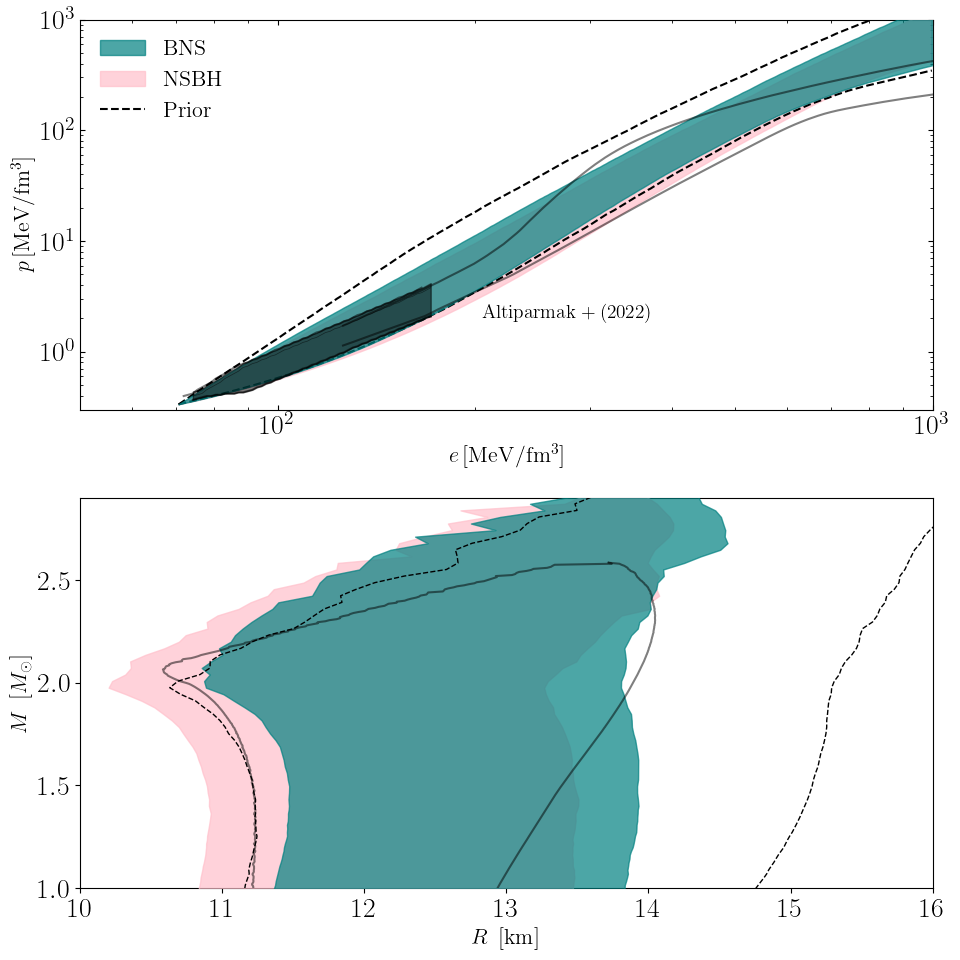

In [86]:

# CET eos
CET=np.loadtxt("CET.txt")

# pQCD band
pQCD=np.loadtxt("pQCD.txt")


# outer contours
constraint1=np.loadtxt("cloudEOS2p0.txt")
constraint2=np.loadtxt("cloudEOS2p18.txt")
constraint3=np.loadtxt("cloudEOS2p35.txt")
constraint4=np.loadtxt("cloudEOS2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1peMtov2p0.dat")
cont2=np.loadtxt("cont0p1peMtov2p18.dat")
cont3=np.loadtxt("cont0p1peMtov2p35.dat")
cont4=np.loadtxt("cont0p1peMtov2p52.dat")


# generating a figure
fig, ax=plt.subplots(2,1,sharex=False,figsize=(10, 10),facecolor='white',dpi=100)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim([50,1*10**3])
ax[0].set_ylim([3e-1,10**3])
#ax.grid(color="gray", linestyle="dashed", linewidth=0.5)
ax[0].tick_params(which='major', direction='in',top="true",right="true")
ax[0].tick_params(which='minor', direction='in',top="true",right="true")
ax[0].set_xlabel(r'$e\,\rm [MeV/fm^3]$', fontsize = 16)
ax[0].set_ylabel(r'$p\,\rm [MeV/fm^3]$',fontsize =  16)

ax[0].plot(10**cont1[:,0],10**cont1[:,1],             color = "black"  , linestyle = "solid",zorder=5,alpha=0.5)
ax[0].plot(10**cont1[:,0],10**cont1[:,2],             color = "black"  , linestyle = "solid",zorder=5,alpha=0.5)

ax[0].plot(10**CET[:,0],10**CET[:,1], color = "black", linestyle = "solid",zorder=5,alpha=0.5)
ax[0].plot(10**CET[:,2],10**CET[:,3], color = "black", linestyle = "solid",zorder=5,alpha=0.5)
ax[0].fill_between(10**CET[:,0],10**CET[:,1],1.1*10**CET[:,3], color = "black" ,zorder=5,alpha=0.5)
ax[0].plot(10**CET[:,0],10**CET[:,1], color = "black" ,zorder=5,linewidth=0.5,alpha=0.5)
ax[0].plot(10**CET[:,0],10**CET[:,3], color = "black" ,zorder=5,linewidth=0.5,alpha=0.5)


ax[0].text(205, 2.0 ,r'$\rm Altiparmak+ (2022)$', fontsize = 14, color="black")
#ax[0].text(200, 1.2 ,r'$\rm theory$', fontsize = 14, color="blue")
#plt.text(18000, 1600 ,r'$\rm pQCD$', fontsize = 14,color="green")

#plt.plot(eng_dens,press_low,color='purple')
#plt.plot(eng_dens,press_high,color='purple')

ax[0].fill_between(eng_dens_GW190425_BNS_physics, press_low_GW190425_BNS_physics, press_high_GW190425_BNS_physics, 
                        color='teal', alpha=0.7, label=r'$\rm BNS$', zorder=4)
print(eng_dens_GW190425_NSBH_physics)
ax[0].fill_between(eng_dens_GW190425_BNS_physics, press_low_GW190425_NSBH_physics, press_high_GW190425_NSBH_physics, 
                        color='pink', alpha=0.7, label=r'$\rm NSBH$', zorder=3)
#ax[0].plot(eng_dens_GW170817_physics, press_low_GW170817_physics,color='teal',zorder=4)
#ax[0].plot(eng_dens_GW170817_physics, press_high_GW170817_physics,color='teal',zorder=4)


ax[0].plot(eng_dens_physics_prior, press_low_physics_prior, 
                       color='black', alpha=1.0,linestyle='dashed',zorder=3)
ax[0].plot(eng_dens_physics_prior,press_high_physics_prior, 
                       color='black', alpha=1.0,linestyle='dashed',zorder=3,label=r'$\rm Prior$')
ax[0].legend(loc="upper left",fontsize=16,frameon=False)
#plt.savefig('press_dens_GW170817_w_prior.pdf',dpi=500)

# Now do the mass-radius plot 

# MR-envlope
envel1=np.loadtxt("cloudMR2p0.txt")
envel2=np.loadtxt("cloudMR2p18.txt")
envel3=np.loadtxt("cloudMR2p35.txt")
envel4=np.loadtxt("cloudMR2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1Mtov2p0.dat")
cont2=np.loadtxt("cont0p1Mtov2p18.dat")
cont3=np.loadtxt("cont0p1Mtov2p35.dat")
cont4=np.loadtxt("cont0p1Mtov2p52.dat")
# dirty trick to close the contour
cont4[-1,2]=cont4[-1,1]
cont3[-1,2]=cont3[-1,1]


ax[1].set_xlim([10,16])
ax[1].set_ylim([1,2.9])
ax[1].set_ylabel(r'$ M~\left[M_\odot\right]$',fontsize=16)
ax[1].set_xlabel(r'$R~\left[{\rm km}\right]$',fontsize=16)


# contours
ax[1].plot( cont1[:,1], cont1[:,0], color = "black"  , linestyle = "-",zorder=7,alpha=0.5)
ax[1].plot( cont1[:,2], cont1[:,0], color = "black"  , linestyle = "-",zorder=7,label=r"$M_{\rm TOV}\geq 2.0\,M_\odot$",alpha=0.5)

 
ax[1].fill_betweenx(mass_GW190425_BNS_physics,min_radius_GW190425_BNS_physics,max_radius_GW190425_BNS_physics, color = "teal" ,zorder=5,alpha=0.7)
ax[1].fill_betweenx(mass_GW190425_NSBH_physics,min_radius_GW190425_NSBH_physics,max_radius_GW190425_NSBH_physics, edgecolor = "pink" ,facecolor='pink',zorder=4,alpha=0.7)
ax[1].fill_betweenx(mass_BNS_prior,min_radius_BNS_prior,max_radius_BNS_prior, edgecolor = "black" ,facecolor='none',zorder=7,linestyle='dashed')
#ax[1].fill_betweenx(mass_uniform_prior,min_radius_uniform_prior,max_radius_uniform_prior, edgecolor = "coral" ,facecolor='none',zorder=7,linestyle='dashed')
#ax[0].set_box_aspect(1)
#ax[1].set_box_aspect(1)
plt.tight_layout()
plt.savefig("GW190425_press_dens_MR.pdf")